# VGG16–CoLoRA on OCTMNIST

This notebook presents a clean, tutorial-oriented implementation of **CoLoRA (Convolutional Low-Rank Adaptation)** for OCTMNIST classification with a VGG16 backbone.

The notebook keeps the original model design and training behavior while reorganizing the workflow into four clear stages:

1. configure and load OCTMNIST,
2. build the VGG16–CoLoRA model,
3. train using **training and validation data only**, and
4. load the saved model for a separate **held-out test inference** step.

The accompanying paper uses OCTMNISTv2 with four classes: Choroidal Neovascularization (ChN), Diabetic Macular Edema (DME), Drusen, and Normal. CoLoRA adapts selected VGG16 convolutional blocks through pointwise and depthwise trainable updates while keeping the pretrained convolutional kernels frozen.

**Authors:** Mariano Rivera and Angello Hoyos

## 1. Environment and dependencies

The notebook expects TensorFlow/Keras, MedMNIST, NumPy, pandas, Matplotlib, and scikit-learn.

GPU visibility is configured before TensorFlow is imported. Change `CUDA_VISIBLE_DEVICES` only when a different device is required.

In [14]:
import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

'2'

In [15]:
from pathlib import Path
import gc
import re

import keras
import matplotlib.pyplot as plt
import medmnist
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import layers
from keras.applications import VGG16
from keras.models import Sequential
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

In [16]:
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

physical_gpus = tf.config.list_physical_devices("GPU")
print(f"Visible physical GPUs: {physical_gpus}")

TensorFlow: 2.19.1
Keras: 3.13.1
Visible physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Experiment configuration

`DATASET_MODE` controls which OCTMNIST training split is used:

- `"full"`: the complete original training split.
- `"balanced"`: a deterministic class-balanced subset containing the first 7,754 samples from each class, matching the balancing rule described in the paper.
- `"distilled"`: the precomputed distilled training set stored in `OCTMNISTv2_Distilled.npz`. The file is expected to contain arrays named `X` and `Y`.

Validation always comes from the original MedMNIST validation split. The test split is intentionally **not loaded in this section**; it is loaded only in the final inference section.

`USE_AUGMENTATION=True` preserves the behavior of the original notebook. Set it to `False` when a no-augmentation protocol is desired.

In [17]:
DATASET_KEY = "octmnist"
IMAGE_SIZE = 224
NUM_CLASSES = 4

DATASET_MODE = "distilled"  # "full", "balanced", or "distilled"
DISTILLED_PATH = Path("./OCTMNISTv2_Distilled.npz")

BATCH_SIZE = 8
EPOCHS = 20
RANDOM_SEED = 42
USE_AUGMENTATION = True

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
BACKBONE_WEIGHTS = "imagenet"

COLORA_BLOCKS = (
    "block2_conv",
    "block3_conv",
    "block4_conv",
    "block5_conv",
)

RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "Choroidal Neovascularization",
    1: "Diabetic Macular Edema",
    2: "Drusen",
    3: "Normal",
}
CLASS_ABBREVIATIONS = ["ChN", "DME", "Drusen", "Normal"]

keras.utils.set_random_seed(RANDOM_SEED)

## 3. Loading OCTMNIST

The loading utility keeps the original validation split unchanged and changes only the training split according to `DATASET_MODE`.

For the balanced mode, samples are selected deterministically rather than randomly. For the distilled mode, this notebook **loads** the already distilled subset; it does not repeat the entropy-ranking procedure used to create that file.

In [18]:
def _medmnist_npz_path(dataset_key=DATASET_KEY, image_size=IMAGE_SIZE):
    info = medmnist.INFO[dataset_key]
    suffix = f"_{image_size}" if image_size else ""

    url_key = f"url{suffix}"
    hash_key = f"MD5{suffix}"
    if hash_key not in info:
        hash_key = f"md5{suffix}"

    return Path(
        keras.utils.get_file(
            origin=info[url_key],
            file_hash=info[hash_key],
            hash_algorithm="md5",
        )
    )


def _ensure_channel_axis(images):
    if images.ndim == 3:
        images = images[..., np.newaxis]
    return images


def _class_indices(labels):
    labels = np.asarray(labels)

    if labels.ndim > 1 and labels.shape[-1] == NUM_CLASSES:
        labels = np.argmax(labels, axis=-1)

    labels = labels.reshape(-1)

    if not np.all(np.isfinite(labels)):
        raise ValueError("Labels contain non-finite values.")

    if not np.all(labels == np.floor(labels)):
        raise ValueError("Class labels must contain integer-valued class indices.")

    labels = labels.astype(np.int64)

    if labels.size and (labels.min() < 0 or labels.max() >= NUM_CLASSES):
        raise ValueError(
            f"Class labels must be in the range [0, {NUM_CLASSES - 1}]."
        )

    return labels


def _one_hot(labels):
    labels = _class_indices(labels)
    return keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)


def _balanced_indices(labels):
    labels = _class_indices(labels)
    class_counts = np.bincount(labels, minlength=NUM_CLASSES)
    samples_per_class = int(class_counts.min())

    selected = [
        np.flatnonzero(labels == class_id)[:samples_per_class]
        for class_id in range(NUM_CLASSES)
    ]
    return np.sort(np.concatenate(selected)), samples_per_class


def load_octmnist_training_data(
    mode=DATASET_MODE,
    distilled_path=DISTILLED_PATH,
    dataset_key=DATASET_KEY,
    image_size=IMAGE_SIZE,
):
    mode = mode.lower()
    if mode not in {"full", "balanced", "distilled"}:
        raise ValueError("mode must be 'full', 'balanced', or 'distilled'.")

    data_path = _medmnist_npz_path(dataset_key, image_size)

    with np.load(data_path) as data:
        val_images = np.array(data["val_images"])
        val_labels = _class_indices(data["val_labels"])

        if mode in {"full", "balanced"}:
            train_images = np.array(data["train_images"])
            train_labels = _class_indices(data["train_labels"])

    if mode == "balanced":
        selected_indices, samples_per_class = _balanced_indices(train_labels)
        train_images = train_images[selected_indices]
        train_labels = train_labels[selected_indices]
    elif mode == "distilled":
        distilled_path = Path(distilled_path)
        if not distilled_path.exists():
            raise FileNotFoundError(
                f"Distilled dataset not found: {distilled_path.resolve()}"
            )

        with np.load(distilled_path) as distilled_data:
            missing_keys = {"X", "Y"} - set(distilled_data.files)
            if missing_keys:
                raise KeyError(
                    f"Distilled file is missing keys: {sorted(missing_keys)}"
                )
            train_images = np.array(distilled_data["X"])
            train_labels = _class_indices(distilled_data["Y"])

    train_images = _ensure_channel_axis(train_images)
    val_images = _ensure_channel_axis(val_images)

    metadata = {
        "mode": mode,
        "train_samples": int(train_images.shape[0]),
        "validation_samples": int(val_images.shape[0]),
        "train_class_counts": np.bincount(
            train_labels, minlength=NUM_CLASSES
        ),
    }

    return (
        (train_images, _one_hot(train_labels)),
        (val_images, _one_hot(val_labels)),
        metadata,
    )


def load_octmnist_test_data(
    dataset_key=DATASET_KEY,
    image_size=IMAGE_SIZE,
):
    data_path = _medmnist_npz_path(dataset_key, image_size)

    with np.load(data_path) as data:
        test_images = _ensure_channel_axis(np.array(data["test_images"]))
        test_labels = _class_indices(data["test_labels"])

    return test_images, _one_hot(test_labels)

In [19]:
(train_images, train_labels), (val_images, val_labels), dataset_metadata = (
    load_octmnist_training_data()
)

print(f"Dataset mode: {dataset_metadata['mode']}")
print(f"Train:      {train_images.shape}  {train_labels.shape}")
print(f"Validation: {val_images.shape}  {val_labels.shape}")

class_distribution = pd.DataFrame(
    {
        "Class": [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
        "Samples": dataset_metadata["train_class_counts"],
    }
)
display(class_distribution)

Dataset mode: distilled
Train:      (28160, 224, 224, 1)  (28160, 4)
Validation: (10832, 224, 224, 1)  (10832, 4)


,Class,Samples
0,Choroidal Neovascularization,7040
1,Diabetic Macular Edema,7040
2,Drusen,7040
3,Normal,7040


### Quick visual inspection

A small inspection step makes the notebook easier to use as a tutorial and verifies that the expected retinal-disease classes are present before training.

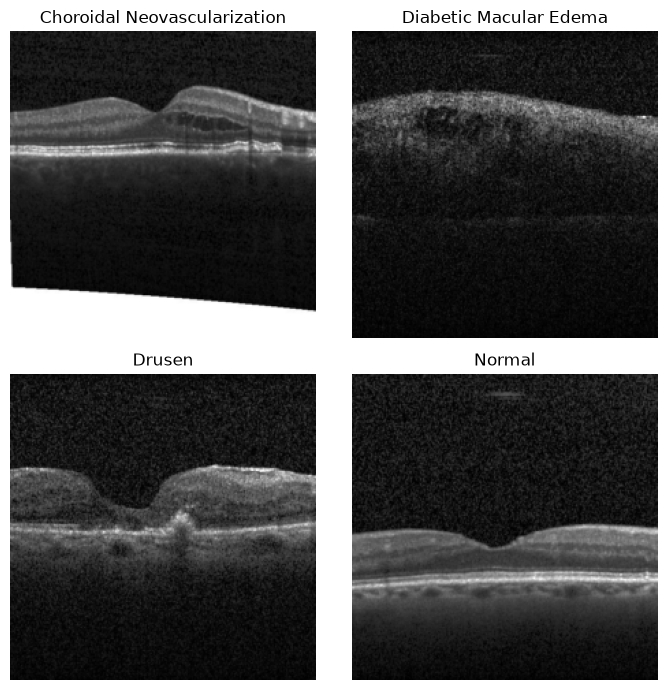

In [20]:
label_ids = np.argmax(train_labels, axis=1)
first_indices = [np.flatnonzero(label_ids == class_id)[0] for class_id in range(NUM_CLASSES)]

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for class_id, ax in enumerate(axes.flat):
    image = np.squeeze(train_images[first_indices[class_id]])
    ax.imshow(image, cmap="gray")
    ax.set_title(CLASS_NAMES[class_id])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. TensorFlow input pipeline

Images are converted from grayscale to RGB because the ImageNet-pretrained VGG16 backbone expects three channels. Pixel values remain on the same 0–255 scale used by the original notebook.

Only the training pipeline is shuffled and optionally augmented. Validation remains deterministic.

In [21]:
AUTOTUNE = tf.data.AUTOTUNE


def augment_image(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.flip_left_right(image)
    return image, label


def prepare_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    return image, label


def build_training_datasets(
    train_images,
    train_labels,
    val_images,
    val_labels,
    batch_size=BATCH_SIZE,
    use_augmentation=USE_AUGMENTATION,
    seed=RANDOM_SEED,
):
    train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    train_ds = train_ds.shuffle(
        buffer_size=min(len(train_images), 10_000),
        seed=seed,
        reshuffle_each_iteration=True,
    )

    if use_augmentation:
        train_ds = train_ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    train_ds = train_ds.map(prepare_image, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.repeat().batch(batch_size).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
    val_ds = val_ds.map(prepare_image, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(AUTOTUNE)

    steps_per_epoch = int(np.ceil(len(train_images) / batch_size))
    return train_ds, val_ds, steps_per_epoch


ds_train, ds_val, STEPS_PER_EPOCH = build_training_datasets(
    train_images,
    train_labels,
    val_images,
    val_labels,
)

del train_images, train_labels, val_images, val_labels
gc.collect()

10956

## 5. VGG16–CoLoRA model

The VGG16 backbone is reconstructed with explicit activation layers so that CoLoRA can be attached to the convolution itself while preserving the original ReLU operations.

For a selected convolution, `Colora2D` keeps the pretrained convolution frozen and adds a trainable pointwise–depthwise path. During training, the residual update is added to the original convolution output. Before the model is saved, the learned update is merged into the original convolution kernel so inference uses the frozen convolution path.

In [22]:
VGG16_LAYER_NAMES = [
    "block1_conv1", "activa1_1", "block1_conv2", "activa1_2", "block1_pool",
    "block2_conv1", "activa2_1", "block2_conv2", "activa2_2", "block2_pool",
    "block3_conv1", "activa3_1", "block3_conv2", "activa3_2",
    "block3_conv3", "activa3_3", "block3_pool",
    "block4_conv1", "activa4_1", "block4_conv2", "activa4_2",
    "block4_conv3", "activa4_3", "block4_pool",
    "block5_conv1", "activa5_1", "block5_conv2", "activa5_2",
    "block5_conv3", "activa5_3", "block5_pool",
]


def build_extended_vgg16(img_size=IMAGE_SIZE):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    x = layers.Conv2D(64, 3, padding="same", name=VGG16_LAYER_NAMES[0])(inputs)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[1])(x)
    x = layers.Conv2D(64, 3, padding="same", name=VGG16_LAYER_NAMES[2])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[3])(x)
    x = layers.MaxPool2D(2, 2, name=VGG16_LAYER_NAMES[4])(x)

    x = layers.Conv2D(128, 3, padding="same", name=VGG16_LAYER_NAMES[5])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[6])(x)
    x = layers.Conv2D(128, 3, padding="same", name=VGG16_LAYER_NAMES[7])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[8])(x)
    x = layers.MaxPool2D(2, 2, name=VGG16_LAYER_NAMES[9])(x)

    x = layers.Conv2D(256, 3, padding="same", name=VGG16_LAYER_NAMES[10])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[11])(x)
    x = layers.Conv2D(256, 3, padding="same", name=VGG16_LAYER_NAMES[12])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[13])(x)
    x = layers.Conv2D(256, 3, padding="same", name=VGG16_LAYER_NAMES[14])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[15])(x)
    x = layers.MaxPool2D(2, 2, name=VGG16_LAYER_NAMES[16])(x)

    x = layers.Conv2D(512, 3, padding="same", name=VGG16_LAYER_NAMES[17])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[18])(x)
    x = layers.Conv2D(512, 3, padding="same", name=VGG16_LAYER_NAMES[19])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[20])(x)
    x = layers.Conv2D(512, 3, padding="same", name=VGG16_LAYER_NAMES[21])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[22])(x)
    x = layers.MaxPool2D(2, 2, name=VGG16_LAYER_NAMES[23])(x)

    x = layers.Conv2D(512, 3, padding="same", name=VGG16_LAYER_NAMES[24])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[25])(x)
    x = layers.Conv2D(512, 3, padding="same", name=VGG16_LAYER_NAMES[26])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[27])(x)
    x = layers.Conv2D(512, 3, padding="same", name=VGG16_LAYER_NAMES[28])(x)
    x = layers.Activation("relu", name=VGG16_LAYER_NAMES[29])(x)

    outputs = layers.MaxPool2D(2, 2, name=VGG16_LAYER_NAMES[30])(x)
    return keras.Model(inputs, outputs, name="vgg16")


def clone_vgg16_with_explicit_activations(pretrained_backbone):
    clone = build_extended_vgg16(img_size=IMAGE_SIZE)

    for layer in pretrained_backbone.layers:
        if isinstance(layer, layers.Conv2D):
            clone.get_layer(layer.name).set_weights(layer.get_weights())

    return clone

In [23]:
@keras.saving.register_keras_serializable(package="CoLoRA")
class Colora2D(keras.layers.Layer):
    def __init__(self, original_layer, trainable=True, **kwargs):
        original_config = original_layer.get_config()
        name = kwargs.pop("name", f"{original_config['name']}_Colora")
        super().__init__(name=name, trainable=trainable, **kwargs)

        self.original_layer = original_layer
        self.original_layer.trainable = False

        self.conv_1x1 = layers.Conv2D(
            filters=original_config["filters"],
            kernel_size=(1, 1),
            strides=(1, 1),
            padding=original_config["padding"],
            activation=original_config["activation"],
            use_bias=original_config["use_bias"],
            kernel_initializer="glorot_uniform",
        )

        self.conv_3x3 = layers.DepthwiseConv2D(
            kernel_size=original_config["kernel_size"],
            strides=original_config["strides"],
            padding=original_config["padding"],
            depth_multiplier=1,
            activation=original_config["activation"],
            use_bias=original_config["use_bias"],
            depthwise_initializer="zeros",
        )

    def build(self, input_shape):
        if not self.original_layer.built:
            self.original_layer.build(input_shape)

        if not self.conv_1x1.built:
            self.conv_1x1.build(input_shape)

        intermediate_shape = self.conv_1x1.compute_output_shape(input_shape)
        if not self.conv_3x3.built:
            self.conv_3x3.build(intermediate_shape)

        super().build(input_shape)

    def call(self, inputs, training=None):
        original_output = self.original_layer(inputs)

        if training:
            update = self.conv_3x3(self.conv_1x1(inputs))
            return original_output + update

        return original_output

    def get_config(self):
        config = super().get_config()
        config["original_layer"] = keras.saving.serialize_keras_object(
            self.original_layer
        )
        return config

    @classmethod
    def from_config(cls, config):
        original_layer_config = config.pop("original_layer")
        original_layer = keras.saving.deserialize_keras_object(
            original_layer_config
        )
        return cls(original_layer=original_layer, **config)

    def merge_filters(self):
        original_weights = self.original_layer.get_weights()
        pointwise_weights = self.conv_1x1.get_weights()
        depthwise_weights = self.conv_3x3.get_weights()

        original_kernel = original_weights[0]
        original_bias = original_weights[1] if len(original_weights) > 1 else None

        pointwise_kernel = pointwise_weights[0]
        depthwise_kernel = depthwise_weights[0]
        depthwise_bias = depthwise_weights[1] if len(depthwise_weights) > 1 else None

        combined_kernel = tf.einsum(
            "abcd,efdg->efcd",
            pointwise_kernel,
            depthwise_kernel,
        ).numpy()

        merged_kernel = original_kernel + combined_kernel

        if original_bias is not None and depthwise_bias is not None:
            self.original_layer.set_weights(
                [merged_kernel, original_bias + depthwise_bias]
            )
        else:
            self.original_layer.set_weights([merged_kernel])

        reset_depthwise = np.zeros_like(depthwise_kernel)
        if depthwise_bias is not None:
            self.conv_3x3.set_weights(
                [reset_depthwise, np.zeros_like(depthwise_bias)]
            )
        else:
            self.conv_3x3.set_weights([reset_depthwise])

        reset_pointwise = keras.initializers.GlorotUniform()(
            self.conv_1x1.kernel.shape
        ).numpy()

        if len(pointwise_weights) > 1:
            self.conv_1x1.set_weights(
                [reset_pointwise, np.zeros_like(pointwise_weights[1])]
            )
        else:
            self.conv_1x1.set_weights([reset_pointwise])

    def set_training_mode(self, mode="tuning"):
        mode = mode.lower()
        if mode == "tuning":
            trainable_flags = (False, True, True)
        elif mode == "original":
            trainable_flags = (True, False, False)
        elif mode == "full":
            trainable_flags = (True, True, True)
        elif mode in {"freeze", "freaze"}:
            trainable_flags = (False, False, False)
        else:
            raise ValueError(
                "mode must be 'tuning', 'original', 'full', or 'freeze'."
            )

        (
            self.original_layer.trainable,
            self.conv_1x1.trainable,
            self.conv_3x3.trainable,
        ) = trainable_flags

In [24]:
def create_vgg16_classifier(weights=BACKBONE_WEIGHTS):
    pretrained_backbone = VGG16(
        weights=weights,
        include_top=False,
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    )
    backbone = clone_vgg16_with_explicit_activations(pretrained_backbone)
    backbone.trainable = False

    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.Conv2D(
        128,
        kernel_size=(1, 1),
        padding="same",
        activation="relu",
        name="compresser",
    )(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu", name="fc_1")(x)
    outputs = layers.Dense(NUM_CLASSES, name="fc_2")(x)

    model = keras.Model(inputs, outputs, name="vgg16_based")
    del pretrained_backbone
    return model


def add_colora_by_block(original_model, block_prefixes):
    block_prefixes = tuple(block_prefixes)
    model = Sequential(name="vgg16_colora")
    model.add(keras.Input(shape=original_model.input_shape[1:]))

    for layer in original_model.layers[1:]:
        if layer.name == "vgg16":
            for backbone_layer in layer.layers:
                # The Sequential model already has its own input specification.
                if isinstance(backbone_layer, layers.InputLayer):
                    continue

                should_adapt = (
                    isinstance(backbone_layer, layers.Conv2D)
                    and any(
                        backbone_layer.name.startswith(prefix)
                        for prefix in block_prefixes
                    )
                )
                model.add(
                    Colora2D(backbone_layer)
                    if should_adapt
                    else backbone_layer
                )
        else:
            model.add(layer)

    return model


def set_colora_training(model, mode="tuning"):
    for layer in model.layers:
        if isinstance(layer, Colora2D):
            layer.set_training_mode(mode)


def merge_colora_filters(model):
    for layer in model.layers:
        if isinstance(layer, Colora2D):
            layer.merge_filters()


def count_model_parameters(model):
    trainable = int(
        sum(np.prod(variable.shape) for variable in model.trainable_weights)
    )
    return {
        "Total parameters": int(model.count_params()),
        "Trainable parameters": trainable,
    }

## 6. Training with train/validation data only

The held-out test split is excluded from this function. Training uses the training dataset, while validation accuracy is used to select the best checkpoint.

The function performs **one training run**. Repeated experiments can be launched explicitly by calling the function again with a different seed, which keeps repeated-run orchestration separate from the core training logic.

To preserve the current notebook behavior, CoLoRA updates are merged only after the validation-selected checkpoint is restored. This avoids changing the optimization dynamics of the supplied implementation.

In [25]:
def collect_predictions(model, dataset, training=False):
    logits_batches = []
    label_batches = []

    for images, labels in dataset:
        logits_batches.append(model(images, training=training).numpy())
        label_batches.append(labels.numpy())

    return (
        np.concatenate(logits_batches, axis=0),
        np.concatenate(label_batches, axis=0),
    )


def _experiment_tag(blocks):
    if not blocks:
        return "transfer_learning"

    block_numbers = []
    for block in blocks:
        match = re.search(r"block(\d+)", block)
        if match:
            block_numbers.append(match.group(1))

    if block_numbers:
        return "blocks_" + "_".join(block_numbers)

    return "_".join(blocks)


def train_model(
    blocks=COLORA_BLOCKS,
    epochs=EPOCHS,
    seed=RANDOM_SEED,
    dataset_mode=DATASET_MODE,
    output_root=RESULTS_DIR,
    weights=BACKBONE_WEIGHTS,
):
    keras.utils.set_random_seed(seed)

    base_model = create_vgg16_classifier(weights=weights)
    model = add_colora_by_block(base_model, blocks)
    del base_model
    gc.collect()

    set_colora_training(model, mode="tuning")

    optimizer = keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    model.compile(
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        optimizer=optimizer,
        metrics=["accuracy"],
        jit_compile=False,
    )

    model.summary(expand_nested=True)
    display(pd.Series(count_model_parameters(model), name="Value").to_frame())

    best_val_accuracy = -np.inf
    best_epoch = None
    best_weights = None
    history_rows = []

    for epoch in range(1, epochs + 1):
        fit_history = model.fit(
            ds_train,
            steps_per_epoch=STEPS_PER_EPOCH,
            epochs=1,
            verbose=1,
        )

        val_logits, val_labels = collect_predictions(
            model,
            ds_val,
            training=True,
        )

        val_true = np.argmax(val_labels, axis=1)
        val_pred = np.argmax(val_logits, axis=1)
        val_accuracy = float(np.mean(val_true == val_pred))
        val_loss = float(
            keras.losses.BinaryCrossentropy(from_logits=True)(
                val_labels,
                val_logits,
            ).numpy()
        )

        train_loss = float(fit_history.history["loss"][-1])
        train_accuracy = float(fit_history.history["accuracy"][-1])

        history_rows.append(
            {
                "Epoch": epoch,
                "Train Loss": train_loss,
                "Train Accuracy": train_accuracy,
                "Validation Loss": val_loss,
                "Validation Accuracy": val_accuracy,
            }
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_weights = [
                np.array(weight, copy=True)
                for weight in model.get_weights()
            ]
            print(
                f"Best validation accuracy: {best_val_accuracy:.6f} "
                f"(epoch {best_epoch})"
            )

    if best_weights is None:
        raise RuntimeError("No validation checkpoint was stored.")

    model.set_weights(best_weights)
    merge_colora_filters(model)

    experiment_tag = _experiment_tag(blocks)
    experiment_dir = Path(output_root) / f"{dataset_mode}_{experiment_tag}"
    experiment_dir.mkdir(parents=True, exist_ok=True)

    model_path = experiment_dir / "best_validation_model.keras"
    history_path = experiment_dir / "training_history.csv"

    model.save(model_path)

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(history_path, index=False)

    print(f"Selected epoch: {best_epoch}")
    print(f"Best validation accuracy: {best_val_accuracy:.6f}")
    print(f"Saved model: {model_path}")
    print(f"Saved history: {history_path}")

    return model_path, history_df

### Train the selected CoLoRA configuration

The default configuration adapts VGG16 blocks 2–5. Change `COLORA_BLOCKS` to reproduce other placement configurations, or pass an empty tuple for classifier-only transfer learning.

In [ ]:
trained_model_path, training_history = train_model(
    blocks=COLORA_BLOCKS,
    epochs= EPOCHS,
    seed=RANDOM_SEED,
)

Model: "vgg16_colora"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa1_1 (Activation)          │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa1_2 (Activation)          │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1_Colora (Colora2D)  │ (None, 112, 112, 128)  │        83,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa2_1 (Activation)          │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2_Colora (Colora2D)  │ (None, 112, 112, 128)  │       165,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa2_2 (Activation)          │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1_Colora (Colora2D)  │ (None, 56, 56, 256)    │       330,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa3_1 (Activation)          │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2_Colora (Colora2D)  │ (None, 56, 56, 256)    │       658,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa3_2 (Activation)          │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3_Colora (Colora2D)  │ (None, 56, 56, 256)    │       658,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa3_3 (Activation)          │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1_Colora (Colora2D)  │ (None, 28, 28, 512)    │     1,316,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa4_1 (Activation)          │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2_Colora (Colora2D)  │ (None, 28, 28, 512)    │     2,627,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa4_2 (Activation)          │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3_Colora (Colora2D)  │ (None, 28, 28, 512)    │     2,627,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activa4_3 (Activation)          │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1_Colora (Colora2D)  │ (None, 14, 14, 512)    │     2,627,58

 Total params: 17,259,076 (65.84 MB)

 Trainable params: 2,544,388 (9.71 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Value
Total parameters,17259076
Trainable parameters,2544388


3520/3520 ━━━━━━━━━━━━━━━━━━━━ 206s 58ms/step - accuracy: 0.8618 - loss: 0.1840
Best validation accuracy: 0.945901 (epoch 1)
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 204s 58ms/step - accuracy: 0.9392 - loss: 0.0867
Best validation accuracy: 0.955133 (epoch 2)
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 205s 58ms/step - accuracy: 0.9615 - loss: 0.0563
Best validation accuracy: 0.961318 (epoch 3)
Selected epoch: 3
Best validation accuracy: 0.961318
Saved model: results/distilled_blocks_2_3_4_5/best_validation_model.keras
Saved history: results/distilled_blocks_2_3_4_5/training_history.csv


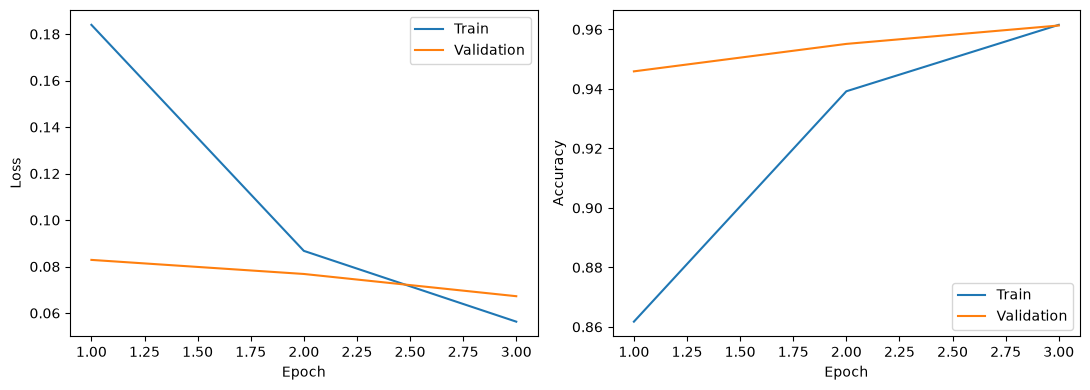

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(training_history["Epoch"], training_history["Train Loss"], label="Train")
axes[0].plot(
    training_history["Epoch"],
    training_history["Validation Loss"],
    label="Validation",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    training_history["Epoch"],
    training_history["Train Accuracy"],
    label="Train",
)
axes[1].plot(
    training_history["Epoch"],
    training_history["Validation Accuracy"],
    label="Validation",
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Held-out test inference

The test set is loaded only after training is complete. The saved, validation-selected model is reloaded from disk and evaluated once.

The reported outputs include:

- test loss,
- overall accuracy,
- macro one-vs-rest AUC,
- macro precision, recall, and F1,
- class-wise AUC, precision, recall, specificity, and F1,
- confusion matrix.

This separation makes the training and evaluation protocol explicit and prevents the test set from influencing model selection.

In [28]:
def build_test_dataset(test_images, test_labels, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    dataset = dataset.map(prepare_image, num_parallel_calls=AUTOTUNE)
    return dataset.batch(batch_size).prefetch(AUTOTUNE)


def evaluate_logits(logits, labels_one_hot):
    probabilities = tf.nn.softmax(logits, axis=1).numpy()
    y_true = np.argmax(labels_one_hot, axis=1)
    y_pred = np.argmax(probabilities, axis=1)

    test_loss = float(
        keras.losses.BinaryCrossentropy(from_logits=True)(
            labels_one_hot,
            logits,
        ).numpy()
    )
    accuracy = float(np.mean(y_true == y_pred))

    auc_per_class = []
    for class_id in range(NUM_CLASSES):
        auc_per_class.append(
            roc_auc_score(
                labels_one_hot[:, class_id],
                probabilities[:, class_id],
            )
        )

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        zero_division=0,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
    )

    specificity = []
    total = matrix.sum()
    for class_id in range(NUM_CLASSES):
        tp = matrix[class_id, class_id]
        fn = matrix[class_id, :].sum() - tp
        fp = matrix[:, class_id].sum() - tp
        tn = total - tp - fn - fp
        specificity.append(tn / (tn + fp) if (tn + fp) else np.nan)

    summary = pd.Series(
        {
            "Test Loss": test_loss,
            "Accuracy": accuracy,
            "Macro AUC (OvR)": float(np.mean(auc_per_class)),
            "Macro Precision": float(np.mean(precision)),
            "Macro Recall": float(np.mean(recall)),
            "Macro F1": float(np.mean(f1)),
        },
        name="Value",
    )

    per_class = pd.DataFrame(
        {
            "Class": CLASS_ABBREVIATIONS,
            "AUC": auc_per_class,
            "Recall": recall,
            "Precision": precision,
            "Specificity": specificity,
            "F1": f1,
        }
    )

    return summary, per_class, matrix


def evaluate_saved_model(model_path, test_dataset):
    model = keras.models.load_model(
        model_path,
        custom_objects={"Colora2D": Colora2D},
    )

    logits, labels_one_hot = collect_predictions(
        model,
        test_dataset,
        training=False,
    )
    return model, *evaluate_logits(logits, labels_one_hot)

In [29]:
test_images, test_labels = load_octmnist_test_data()
ds_test = build_test_dataset(test_images, test_labels)

loaded_model, test_summary, class_metrics, test_confusion_matrix = (
    evaluate_saved_model(trained_model_path, ds_test)
)

display(test_summary.to_frame())
display(class_metrics)

,Value
Test Loss,0.191548
Accuracy,0.884000
Macro AUC (OvR),0.990215
Macro Precision,0.911397
Macro Recall,0.884000
Macro F1,0.879912


,Class,AUC,Recall,Precision,Specificity,F1
0,ChN,0.988973,0.992,0.716763,0.869333,0.832215
1,DME,0.993611,0.944,0.995781,0.998667,0.969199
2,Drusen,0.980085,0.604,0.993421,0.998667,0.751244
3,Normal,0.998192,0.996,0.939623,0.978667,0.966990


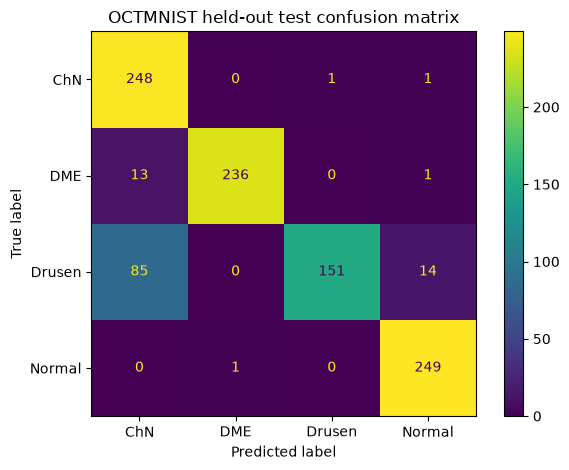

In [30]:
display_object = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=CLASS_ABBREVIATIONS,
)
display_object.plot(values_format="d")
plt.title("OCTMNIST held-out test confusion matrix")
plt.tight_layout()
plt.show()

## 8. Reusing the notebook

The main experiment can be changed without editing the model implementation:

- set `DATASET_MODE` to `"full"`, `"balanced"`, or `"distilled"`;
- change `COLORA_BLOCKS` to select which VGG16 blocks receive CoLoRA;
- set `USE_AUGMENTATION=False` when augmentation should be disabled;
- call `train_model(...)` with a different seed for an independent run;
- set `trained_model_path` to an existing `.keras` file when only inference is required.

The test section remains independent of training, so a previously trained model can be evaluated without rerunning the optimization stage.